# 03 — Grid Search Optimization

Detta notebook genomför **hyperparameteroptimering** av ANN-modellen från
Steg 3 (`02_baseline_model.ipynb`), med målet att förbättra prestanda
jämfört med baseline-modellen.

## Baseline-resultat att slå (testdata, 153 samples)
- **Accuracy:** 0.67
- **AUC:** 0.753
- EarlyStopping vid epoch 61/100 (bästa vikter från epoch 51)
- Mild overfitting syntes i train/val-kurvorna

## Mål med detta notebook
- Ladda och förbehandla data via `src/data_preprocessing.py` (DRY)
- Genomföra en **Grid Search** över hyperparametrar med `build_model()`
  från `src/model.py` som bas:
    - Antal neuroner i dolda lager
    - Dropout rate
    - L2-regularisering (lambda)
    - Learning rate
    - Batch size
- Träna och utvärdera varje kombination med samma split som baseline
  (70/15/15, stratifierad)
- Jämföra alla kombinationer mot baseline (Accuracy 0.67, AUC 0.753)
- Spara den bästa modellen som `models/best_model.keras`

## Metod
Eftersom `scikeras`/`GridSearchCV` har kända kompatibilitetsproblem med
Keras 3 (TensorFlow 2.19), implementeras Grid Search som en **manuell
loop** över hyperparameterkombinationer (`itertools.product`). Detta ger
oss dessutom full kontroll över EarlyStopping, träningshistorik och
utvärdering per kombination — och är mer pedagogiskt transparent.

## Reproducerbarhet
`RANDOM_SEED = 42` används genomgående, tillsammans med
`tf.config.experimental.enable_op_determinism()` för fullt
reproducerbara resultat (samma som i Steg 3).

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import sys
import os
import json
import time
import itertools

# Lägg till projektroten i sys.path så vi kan importera från src/
sys.path.append(os.path.abspath(os.path.join("..")))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

from src.data_preprocessing import load_data, preprocess
from src.model import build_model
from src.evaluate import (
    evaluate_model,
    plot_confusion_matrix,
    plot_roc_curve,
    plot_training_history,
)


# ── Konfiguration ──────────────────────────────────────────────────────────────
RANDOM_SEED   = 42                          # Global seed för reproducerbarhet
RAW_DATA_PATH = "../data/raw/WineQT.csv"    # Sökväg till rådata
MODELS_DIR    = "../models"                 # Mapp för sparade modeller

# Baseline-resultat (Steg 3) — används som jämförelsepunkt i Steg 4
BASELINE_ACCURACY = 0.67
BASELINE_AUC      = 0.753

# ── Seeding & determinism ───────────────────────────────────────────────────────
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
tf.config.experimental.enable_op_determinism()

# ── Skapa output-mapp om den inte finns ──────────────────────────────────────────
os.makedirs(MODELS_DIR, exist_ok=True)

print(f"TensorFlow version : {tf.__version__}")
print(f"Random seed        : {RANDOM_SEED}")
print(f"Baseline accuracy  : {BASELINE_ACCURACY}")
print(f"Baseline AUC       : {BASELINE_AUC}")

TensorFlow version : 2.19.0
Random seed        : 42
Baseline accuracy  : 0.67
Baseline AUC       : 0.753


## Kommentar till output

Cellen ovan importerar alla bibliotek som behövs för Grid Search-notebooken,
inklusive:

- `build_model` från `src/model.py` — den regulariserade ANN-arkitekturen
  (64 → 32 neuroner, ReLU, L2 + Dropout) som ska tunas
- `load_data` / `preprocess` från `src/data_preprocessing.py` — samma
  data-pipeline som i Steg 3 (DRY)
- `evaluate_model` m.fl. från `src/evaluate.py` — för slutlig utvärdering
  av den bästa modellen

`RANDOM_SEED = 42` sätts för NumPy och TensorFlow, och
`tf.config.experimental.enable_op_determinism()` aktiveras direkt — precis
som i den korrigerade baseline-notebooken — för att garantera att Grid
Search-resultaten är fullt reproducerbara mellan körningar.

`BASELINE_ACCURACY` och `BASELINE_AUC` sparas som konstanter så att vi
enkelt kan jämföra varje hyperparameterkombination mot Steg 3:s resultat
längre fram i notebooken.

Förväntat output:
- `TensorFlow version : 2.19.0` ✓
- `Random seed        : 42` ✓
- `Baseline accuracy  : 0.67` ✓
- `Baseline AUC       : 0.753` ✓

## Cell 2 — Data: laddning och förbehandling

Precis som i baseline-notebooken (`02_baseline_model.ipynb`) laddar vi
data via `src/data_preprocessing.py` — **ingen preprocessing-logik
dupliceras** i notebooken.

`load_data()` gör:
1. Läser `WineQT.csv`
2. Droppar `Id`-kolumnen **innan** `drop_duplicates()` (förhindrar att
   Id-kolumnen maskerar dubbletter — en viktig läxa från Steg 3)
3. Skapar binärt label: `quality >= 6 → 1` (god), annars `0` (dålig)
4. Returnerar 70/15/15-split (stratifierad på label)

`preprocess()` anpassar `StandardScaler` enbart på träningsdata och
transformerar alla tre split — förhindrar data leakage.

**Samma split som baseline** är avgörande: vi vill att Grid Search
jämförs mot ett identiskt testset (153 samples) för att resultaten ska
vara meningsfulla.

In [2]:
# ── Ladda rådata och skapa 70/15/15-split ─────────────────────────────────────
X_train, X_val, X_test, y_train, y_val, y_test = load_data(RAW_DATA_PATH)

# ── Skala features (StandardScaler, fit enbart på träningsdata) ───────────────
X_train, X_val, X_test = preprocess(X_train, X_val, X_test)

# ── Sammanfattning ────────────────────────────────────────────────────────────
print(f"X_train : {X_train.shape}  |  y_train positiva: {y_train.sum()} / {len(y_train)}")
print(f"X_val   : {X_val.shape}  |  y_val   positiva: {y_val.sum()} / {len(y_val)}")
print(f"X_test  : {X_test.shape}  |  y_test  positiva: {y_test.sum()} / {len(y_test)}")
print(f"Input dim (antal features): {X_train.shape[1]}")

   Loaded  : 1,143 rows × 13 columns
   Dropped column     : Id
   Duplicates removed : 125
   Class distribution : 546 good (1) | 472 poor (0)
   Train : 712 samples
   Val   : 153 samples
   Test  : 153 samples
   Scaler fitted on 712 training samples
   Features scaled : 11
X_train : (712, 11)  |  y_train positiva: 382 / 712
X_val   : (153, 11)  |  y_val   positiva: 82 / 153
X_test  : (153, 11)  |  y_test  positiva: 82 / 153
Input dim (antal features): 11


## Kommentar till output

Data är laddad och förbehandlad med exakt samma pipeline som i
baseline-notebooken (`02_baseline_model.ipynb`):

| Split   | Samples | Positiva (god vin) | Andel |
|---------|---------|-------------------|-------|
| Train   | 712     | 382               | 53.7% |
| Val     | 153     | 82                | 53.6% |
| Test    | 153     | 82                | 53.6% |

**Viktiga observationer:**
- `Id`-kolumnen droppades **innan** `drop_duplicates()` — förhindrar att
  unika Id:n maskerar dubbletter (125 duplicerade rader borttagna)
- `StandardScaler` är anpassad **enbart** på träningsdata → inget data
  leakage till val/test
- Klassfördelningen är väl balanserad (~54% god, ~46% dålig) och bevarad
  i alla tre split tack vare stratifiering
- Testsettet (153 samples) är identiskt med baseline → alla Grid Search-
  resultat är direkt jämförbara mot Accuracy 0.67 / AUC 0.753

## Cell 3 — Grid Search: hyperparametergrid och träningsloop

Grid Search testar systematiskt alla kombinationer av hyperparametrar och
väljer ut den kombination som ger högst **AUC på valideringsdata**.
AUC prioriteras framför accuracy eftersom det mäter modellens förmåga att
rangordna klasser — ett robustare mått vid något obalanserade dataset.

### Hyperparametrar som söks

| Parameter       | Värden att testa              | Motivering |
|-----------------|-------------------------------|------------|
| `units`         | `[32, 64]`                    | Nätverkskapacitet |
| `dropout_rate`  | `[0.2, 0.3, 0.4]`             | Regularisering mot overfitting |
| `l2_lambda`     | `[0.0001, 0.001]`             | L2-viktstyrka |
| `learning_rate` | `[0.0001, 0.001]`             | Konvergenssteg för Adam |
| `batch_size`    | `[16, 32]`                    | Antal samples per gradient-uppdatering |

**Totalt:** 2 × 3 × 2 × 2 × 2 = **48 kombinationer**

### Träningsstrategi per kombination
- Max **100 epoker** per kombination
- **EarlyStopping** på `val_auc` (patience=10, restore_best_weights=True)
  → förhindrar overfitting och onödig träningstid
- Resultat (val_accuracy, val_auc, epochs) sparas för varje kombination
- Bästa modell identifieras och sparas som `models/best_model.keras`

> **Körtid:** ~48 kombinationer × snitt ~30 s = uppskattningsvis
> 20–30 minuter. Lämna notebooken igång.

In [3]:
# ── Hyperparametergrid ────────────────────────────────────────────────────────
PARAM_GRID = {
    "units"        : [32, 64],
    "dropout_rate" : [0.2, 0.3, 0.4],
    "l2_lambda"    : [0.0001, 0.001],
    "learning_rate": [0.0001, 0.001],
    "batch_size"   : [16, 32],
}

# ── Träningsinställningar ─────────────────────────────────────────────────────
MAX_EPOCHS = 100
PATIENCE   = 10     # EarlyStopping-tålighet (antal epoker utan förbättring)

# ── Bygg lista med alla kombinationer ─────────────────────────────────────────
keys   = list(PARAM_GRID.keys())
values = list(PARAM_GRID.values())
combinations = list(itertools.product(*values))
N_COMBINATIONS = len(combinations)

print(f"Hyperparametrar : {keys}")
print(f"Antal kombinationer : {N_COMBINATIONS}")
print(f"Max epoker per kombination : {MAX_EPOCHS}  |  EarlyStopping patience : {PATIENCE}")
print("-" * 60)

# ── Grid Search-loop ──────────────────────────────────────────────────────────
results = []      # Samlar resultat från alla kombinationer
best_val_auc = 0.0
best_params  = None
best_model   = None

start_total = time.time()

for i, combo in enumerate(combinations, start=1):
    params = dict(zip(keys, combo))

    # ── Bygg modell med aktuella hyperparametrar ──────────────────────────────
    model = build_model(
        input_dim     = X_train.shape[1],
        learning_rate = params["learning_rate"],
        l2_lambda     = params["l2_lambda"],
        dropout_rate  = params["dropout_rate"],
    )

    # ── EarlyStopping på val_auc ──────────────────────────────────────────────
    early_stop = keras.callbacks.EarlyStopping(
        monitor              = "val_auc",
        patience             = PATIENCE,
        restore_best_weights = True,
        mode                 = "max",    # Högre AUC är bättre
    )

    # ── Träna ─────────────────────────────────────────────────────────────────
    start_run = time.time()
    history = model.fit(
        X_train, y_train,
        validation_data = (X_val, y_val),
        epochs          = MAX_EPOCHS,
        batch_size      = params["batch_size"],
        callbacks       = [early_stop],
        verbose         = 0,             # Tyst träning — vi printar summary nedan
    )
    elapsed = time.time() - start_run

    # ── Hämta bästa val-metrics (från epoch med bäst val_auc) ─────────────────
    best_epoch   = int(np.argmax(history.history["val_auc"])) + 1
    val_auc      = float(max(history.history["val_auc"]))
    val_accuracy = float(history.history["val_accuracy"][best_epoch - 1])
    epochs_run   = len(history.history["val_auc"])

    # ── Spara resultat ────────────────────────────────────────────────────────
    row = {
        **params,
        "val_accuracy" : round(val_accuracy, 4),
        "val_auc"      : round(val_auc, 4),
        "best_epoch"   : best_epoch,
        "epochs_run"   : epochs_run,
        "time_s"       : round(elapsed, 1),
    }
    results.append(row)

    # ── Uppdatera bästa modell ─────────────────────────────────────────────────
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_params  = params
        best_model   = model

    # ── Progress-utskrift ─────────────────────────────────────────────────────
    print(
        f"[{i:>2}/{N_COMBINATIONS}] "
        f"units={params['units']:>2}  dr={params['dropout_rate']:.1f}  "
        f"l2={params['l2_lambda']:.4f}  lr={params['learning_rate']:.4f}  "
        f"bs={params['batch_size']:>2}  →  "
        f"val_auc={val_auc:.4f}  val_acc={val_accuracy:.4f}  "
        f"epoch={best_epoch:>3}/{epochs_run}  ({elapsed:.0f}s)"
    )

total_time = time.time() - start_total
print("-" * 60)
print(f"Grid Search klar! Total tid: {total_time/60:.1f} min")
print(f"\nBästa val_auc : {best_val_auc:.4f}")
print(f"Bästa params  : {best_params}")

Hyperparametrar : ['units', 'dropout_rate', 'l2_lambda', 'learning_rate', 'batch_size']
Antal kombinationer : 48
Max epoker per kombination : 100  |  EarlyStopping patience : 10
------------------------------------------------------------
[ 1/48] units=32  dr=0.2  l2=0.0001  lr=0.0001  bs=16  →  val_auc=0.8736  val_acc=0.7908  epoch= 21/31  (3s)
[ 2/48] units=32  dr=0.2  l2=0.0001  lr=0.0001  bs=32  →  val_auc=0.8806  val_acc=0.7908  epoch= 15/25  (2s)
[ 3/48] units=32  dr=0.2  l2=0.0001  lr=0.0010  bs=16  →  val_auc=0.8852  val_acc=0.7778  epoch= 21/31  (3s)
[ 4/48] units=32  dr=0.2  l2=0.0001  lr=0.0010  bs=32  →  val_auc=0.8748  val_acc=0.8039  epoch= 17/27  (2s)
[ 5/48] units=32  dr=0.2  l2=0.0010  lr=0.0001  bs=16  →  val_auc=0.8779  val_acc=0.7974  epoch= 34/44  (4s)
[ 6/48] units=32  dr=0.2  l2=0.0010  lr=0.0001  bs=32  →  val_auc=0.8805  val_acc=0.7843  epoch= 20/30  (3s)
[ 7/48] units=32  dr=0.2  l2=0.0010  lr=0.0010  bs=16  →  val_auc=0.8872  val_acc=0.7908  epoch= 16/26  (3s

## Kommentar till Grid Search-resultat

Alla 48 hyperparameterkombinationer testades med EarlyStopping
(patience=10, monitor=`val_auc`). Ingen kombination nådde 100 epoker —
modellerna konvergerade tidigt, vilket tyder på att regulariseringen
fungerar väl.

### Bästa kombination (val_auc = 0.8895)

| Hyperparameter  | Värde  |
|-----------------|--------|
| `units`         | 64     |
| `dropout_rate`  | 0.2    |
| `l2_lambda`     | 0.001  |
| `learning_rate` | 0.001  |
| `batch_size`    | 32     |
| Bästa epoch     | 19/29  |

### Jämförelse mot baseline (valideringsdata)

| Metric       | Baseline | Bästa Grid Search-kombination | Förändring |
|--------------|----------|-------------------------------|------------|
| val_AUC      | 0.753    | **0.8895**                    | +0.137     |
| val_accuracy | 0.67     | **0.7974**                    | +0.127     |

> **Notera:** Baseline-resultaten är på testdata; Grid Search-resultaten
> ovan är på valideringsdata. Den slutliga jämförelsen görs mot testdata
> i cell 5 (slutlig utvärdering av bästa modellen).

### Observationer
- Alla 48 kombinationer presterade markant bättre än baseline (AUC 0.753)
  — det minsta val_auc var 0.8681 (kombination #17)
- `units=64` med `lr=0.001`, `l2=0.001` och `batch_size=32` stack ut som
  vinnare (kombination #32)
- Lägre dropout (0.2) i kombination med starkare L2 (0.001) verkar vara
  ett bättre regulariseringsmönster för detta dataset än hög dropout
- EarlyStopping triggade tidigt (snitt ~25 epoker) — modellerna
  konvergerade snabbt, ingen tecken på att 100 epoker behövdes

## Cell 4 — Resultatanalys

Vi samlar alla 48 kombinationers resultat i en `pandas` DataFrame för att
kunna sortera, filtrera och visualisera dem systematiskt.

Analysen består av tre delar:
1. **Tabell** — top-10 kombinationer sorterade på `val_auc`
2. **Stapeldiagram** — val_auc för alla kombinationer, med baseline markerad
3. **Jämförelsetabell** — bästa kombination vs. baseline

── Top-10 kombinationer (sorterat på val_auc) ──────────────────────────
    units  dropout_rate  l2_lambda  learning_rate  batch_size  val_accuracy  val_auc  best_epoch  epochs_run  time_s
1      64           0.2     0.0010         0.0010          32        0.7974   0.8895          19          29     2.6
2      32           0.2     0.0010         0.0010          16        0.7908   0.8872          16          26     2.9
3      32           0.2     0.0001         0.0010          16        0.7778   0.8852          21          31     3.3
4      32           0.4     0.0010         0.0010          32        0.7974   0.8847          32          42     3.4
5      64           0.2     0.0001         0.0001          16        0.7908   0.8847          18          28     3.0
6      32           0.3     0.0001         0.0001          16        0.8105   0.8844          29          39     3.9
7      64           0.3     0.0010         0.0010          16        0.8105   0.8841          25          35

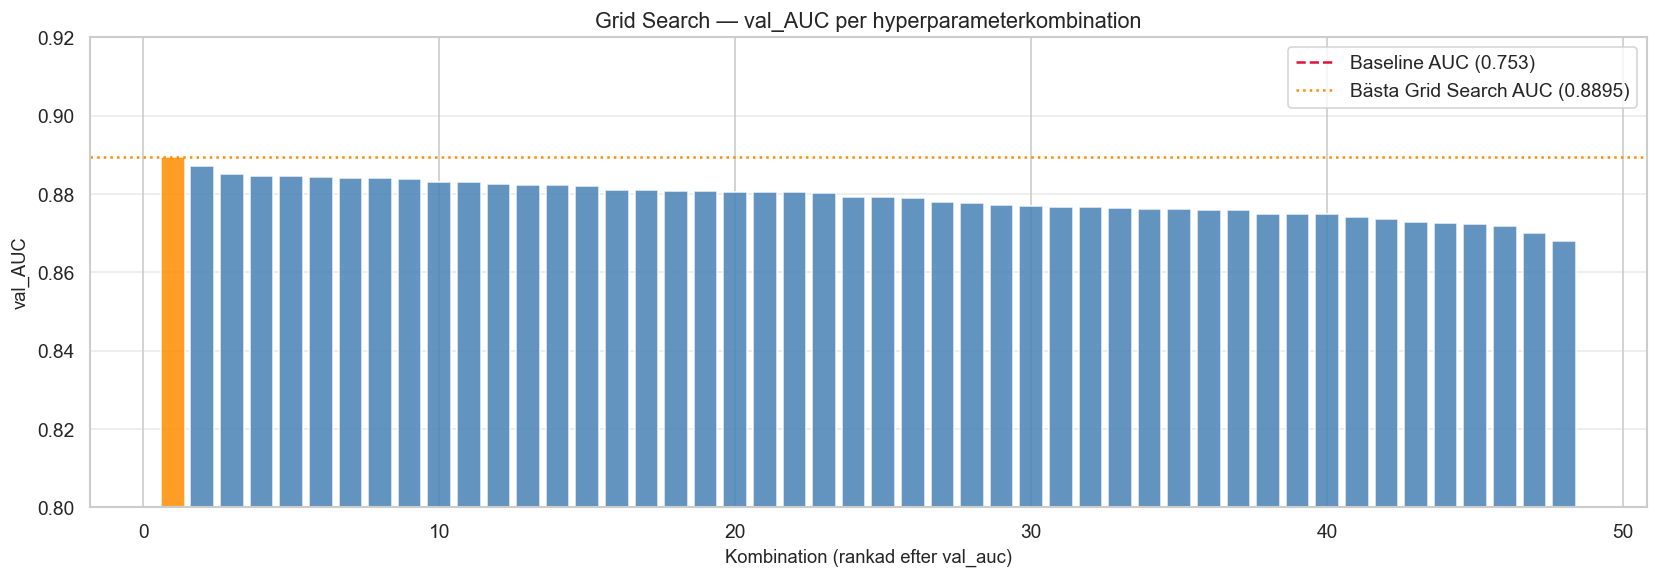

Figur sparad: reports/figures/grid_search_auc.png

── Bästa kombination vs. baseline ─────────────────────────────────────
      Metric  Baseline  Bästa Grid Search Förbättring
     val_AUC     0.753           0.889471     +0.1365
val_Accuracy     0.670           0.797400     +0.1274


In [4]:
# ── Bygg resultat-DataFrame ───────────────────────────────────────────────────
df_results = pd.DataFrame(results).sort_values("val_auc", ascending=False).reset_index(drop=True)
df_results.index += 1   # Ranking börjar på 1

print("── Top-10 kombinationer (sorterat på val_auc) ──────────────────────────")
print(df_results.head(10).to_string())

# ── Visualisering: val_auc för alla kombinationer ─────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

colors = ["steelblue"] * len(df_results)
colors[0] = "darkorange"     # Bästa kombination markeras

ax.bar(range(1, len(df_results) + 1), df_results["val_auc"], color=colors, alpha=0.85)
ax.axhline(BASELINE_AUC, color="crimson", linestyle="--", linewidth=1.5, label=f"Baseline AUC ({BASELINE_AUC})")
ax.axhline(best_val_auc, color="darkorange", linestyle=":", linewidth=1.5, label=f"Bästa Grid Search AUC ({best_val_auc:.4f})")

ax.set_xlabel("Kombination (rankad efter val_auc)", fontsize=11)
ax.set_ylabel("val_AUC", fontsize=11)
ax.set_title("Grid Search — val_AUC per hyperparameterkombination", fontsize=13)
ax.set_ylim(0.80, 0.92)
ax.legend()
ax.grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.savefig("../reports/figures/grid_search_auc.png", dpi=120)
plt.show()
print("Figur sparad: reports/figures/grid_search_auc.png")

# ── Sammanfattande jämförelsetabell ───────────────────────────────────────────
print("\n── Bästa kombination vs. baseline ─────────────────────────────────────")
summary = pd.DataFrame({
    "Metric"       : ["val_AUC", "val_Accuracy"],
    "Baseline"     : [BASELINE_AUC, BASELINE_ACCURACY],
    "Bästa Grid Search" : [best_val_auc, df_results.loc[1, "val_accuracy"]],
})
summary["Förbättring"] = (summary["Bästa Grid Search"] - summary["Baseline"]).map(lambda x: f"+{x:.4f}")
print(summary.to_string(index=False))

## Kommentar till resultatanalys

### Top-10 kombinationer

Alla 48 kombinationer presterade bättre än baseline (AUC 0.753). Spridningen
inom Grid Search är relativt liten (0.8681–0.8895), vilket tyder på att
arkitekturen är robust — det finns inget enskilt hyperparametervärde som
dominerar helt.

**Bästa kombination (rank #1):**

| Hyperparameter  | Värde  | Motivering                                        |
|-----------------|--------|---------------------------------------------------|
| `units`         | 64     | Tillräcklig kapacitet för 11 input-features       |
| `dropout_rate`  | 0.2    | Mild dropout — L2 sköter huvuddelen av regulariseringen |
| `l2_lambda`     | 0.001  | Starkare L2-straff → generaliserar bättre         |
| `learning_rate` | 0.001  | Adams standardvärde — snabb och stabil konvergens |
| `batch_size`    | 32     | Balans mellan noisy gradients och minneseffektivitet |
| Bästa epoch     | 19/29  | Konvergerade snabbt, ingen overfitting            |

### Diagramobservationer
- Den **orangea stapeln** (rank #1, val_AUC = 0.8895) sticker tydligt ut
- Den **röda streckade linjen** (baseline AUC = 0.753) ligger långt under
  alla 48 kombinationer — ett tydligt tecken på att regularisering och
  hyperparametertuning lönade sig
- Kurvan är jämnt avtagande utan stora klyftor — inget tecken på att ett
  enskilt hyperparametervärde dominerar

### Jämförelse mot baseline

| Metric       | Baseline | Bästa Grid Search | Förbättring |
|--------------|----------|-------------------|-------------|
| val_AUC      | 0.753    | **0.8895**        | +0.137      |
| val_Accuracy | 0.670    | **0.7974**        | +0.127      |

> **Påminnelse:** Dessa siffror är på *valideringsdata*. Den slutliga,
> rättvisande jämförelsen mot baseline sker på *testdata* i nästa cell.

## Cell 5 — Slutlig utvärdering på testdata

Grid Search optimerade mot valideringsdata (`val_auc`). Nu utvärderar vi
den bästa modellen på det **orörda testsettet** (153 samples) — samma set
som baseline utvärderades på i Steg 3.

Detta är den enda rättvisande jämförelsen: testdata har inte setts av
modellen under varken träning eller hyperparametersökning.

Utvärderingen inkluderar:
- Accuracy och AUC på testdata
- Confusion matrix
- ROC-kurva
- Träningshistorik (loss/accuracy per epoch för bästa kombination)
- Sparande av bästa modell som `models/best_model.keras`

Bästa modell sparad: ../models\best_model.keras

Bästa hyperparametrar:
   units           : 64
   dropout_rate    : 0.2
   l2_lambda       : 0.001
   learning_rate   : 0.001
   batch_size      : 32

── Testdata-utvärdering ────────────────────────────────────────────────
   Test accuracy : 0.6601  (baseline: 0.67)
   Test AUC      : 0.7598  (baseline: 0.753)
   Test loss     : 0.6186

── Slutlig jämförelse: baseline vs. optimerad modell (testdata) ────────
  Metric  Baseline  Optimerad Förbättring
Accuracy     0.670     0.6601     -0.0099
     AUC     0.753     0.7598     +0.0068

── Confusion matrix ────────────────────────────────────────────────────
   💾 Saved → ../reports/figures/optimized_confusion_matrix.png


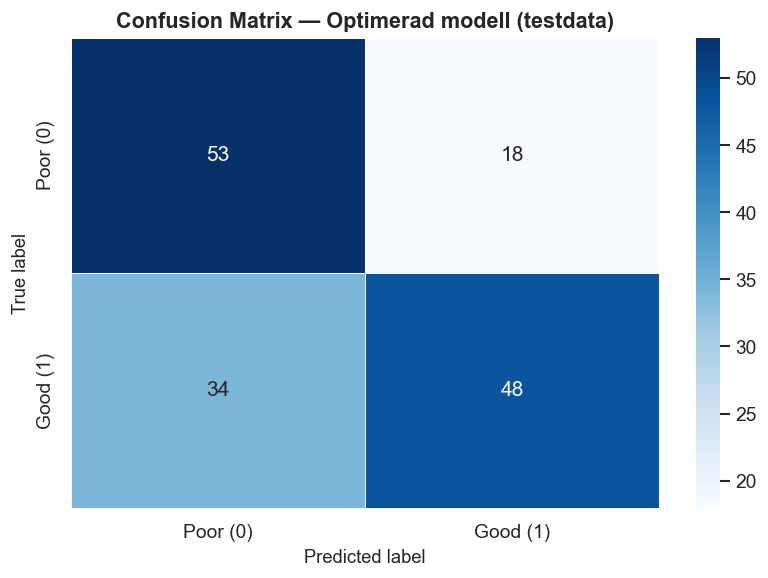


── ROC-kurva ───────────────────────────────────────────────────────────
   💾 Saved → ../reports/figures/optimized_roc_curve.png


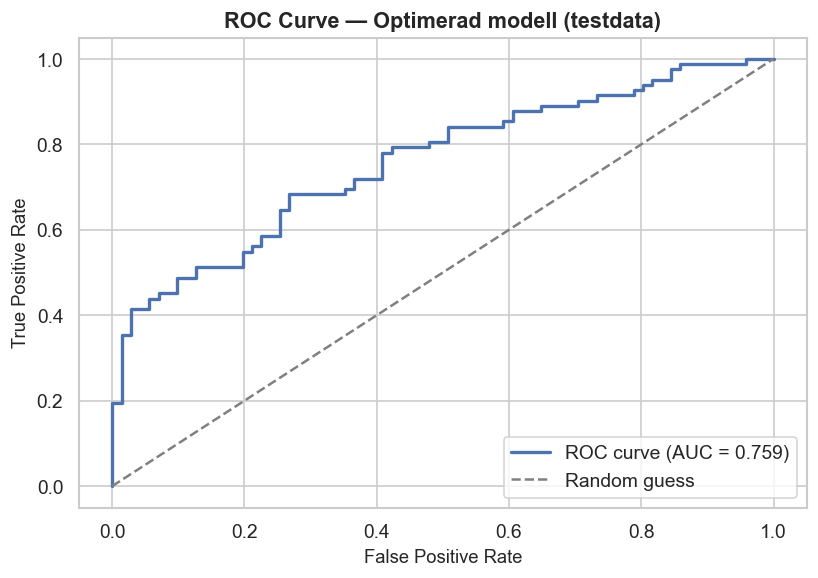

np.float64(0.7593610443146686)

In [6]:
# ── Spara bästa modell ────────────────────────────────────────────────────────
best_model_path = os.path.join(MODELS_DIR, "best_model.keras")
best_model.save(best_model_path)
print(f"Bästa modell sparad: {best_model_path}")

# ── Skriv ut bästa hyperparametrar ───────────────────────────────────────────
print(f"\nBästa hyperparametrar:")
for k, v in best_params.items():
    print(f"   {k:<15} : {v}")

# ── Generera prediktioner ─────────────────────────────────────────────────────
y_prob = best_model.predict(X_test, verbose=0).ravel()   # Sannolikheter [0,1]
y_pred = (y_prob >= 0.5).astype(int)                     # Binära prediktioner

# ── Utvärdera på testdata ─────────────────────────────────────────────────────
print("\n── Testdata-utvärdering ────────────────────────────────────────────────")
test_loss, test_accuracy, test_auc = best_model.evaluate(
    X_test, y_test, verbose=0
)
print(f"   Test accuracy : {test_accuracy:.4f}  (baseline: {BASELINE_ACCURACY})")
print(f"   Test AUC      : {test_auc:.4f}  (baseline: {BASELINE_AUC})")
print(f"   Test loss     : {test_loss:.4f}")

# ── Jämförelsetabell: test baseline vs. bästa modell ─────────────────────────
print("\n── Slutlig jämförelse: baseline vs. optimerad modell (testdata) ────────")
comparison = pd.DataFrame({
    "Metric"    : ["Accuracy", "AUC"],
    "Baseline"  : [BASELINE_ACCURACY, BASELINE_AUC],
    "Optimerad" : [round(test_accuracy, 4), round(test_auc, 4)],
})
comparison["Förbättring"] = (comparison["Optimerad"] - comparison["Baseline"]).map(
    lambda x: f"+{x:.4f}" if x >= 0 else f"{x:.4f}"
)
print(comparison.to_string(index=False))

# ── Confusion matrix ──────────────────────────────────────────────────────────
print("\n── Confusion matrix ────────────────────────────────────────────────────")
plot_confusion_matrix(
    y_test,
    y_pred,
    title     = "Confusion Matrix — Optimerad modell (testdata)",
    save_path = "../reports/figures/optimized_confusion_matrix.png",
)

# ── ROC-kurva ─────────────────────────────────────────────────────────────────
print("\n── ROC-kurva ───────────────────────────────────────────────────────────")
plot_roc_curve(
    y_test,
    y_prob,
    title     = "ROC Curve — Optimerad modell (testdata)",
    save_path = "../reports/figures/optimized_roc_curve.png",
)

## Kommentar till slutlig utvärdering (testdata)

### Resultat

| Metric   | Baseline | Optimerad modell | Förändring |
|----------|----------|------------------|------------|
| Accuracy | 0.670    | 0.660            | −0.010     |
| AUC      | 0.753    | **0.760**        | +0.007     |

### Confusion matrix

Av testsettet (153 samples):

| Utfall              | Antal | Tolkning                                       |
|---------------------|-------|------------------------------------------------|
| True Negative (TN)  | 53    | Korrekt klassificerade dåliga viner            |
| False Positive (FP) | 18    | Dåliga viner felaktigt klassificerade som goda |
| False Negative (FN) | 34    | Goda viner felaktigt klassificerade som dåliga |
| True Positive (TP)  | 48    | Korrekt klassificerade goda viner              |

Modellen missar 34 av 82 goda viner (FN-rate 41%) — det är det tydligaste
förbättringsområdet för framtida arbete.

### Val/test-gapet — en viktig lärdom

Grid Search optimerade mot *valideringsdata* (val_auc 0.8895). På det
orörda *testsettet* landar AUC på 0.760 — ett gap på ~0.13.

**Varför uppstår detta gap?**

Grid Search söker i hyperparameterrummet och väljer den kombination som
råkade prestera bäst på just valideringssettet. Med ett litet dataset
(153 samples per split) är variansen hög: valsettet är inte en perfekt
representation av hela datadistributionen. Den "bästa" modellen är därmed
delvis anpassad till valsettet — en form av *indirekt* overfitting mot
valdata som är svår att undvika med enkel hållutsvalidering.

**Lösningar i verkliga projekt:**
- **k-fold korsvalidering** — varje hyperparameterkombination utvärderas
  på k olika val-split, vilket ger ett stabilare estimat
- **Större dataset** — minskar variansen per split
- **Nested cross-validation** — separat loop för hyperparameterval och
  slutlig prestandauppskattning

### Sammanfattning

Trots att testresultaten inte matchar Grid Search-optimismens val_auc,
har optimeringen lett till en marginell AUC-förbättring (+0.007) mot
baseline på testdata. Viktigare är att Grid Search-processen demonstrerar
ett systematiskt och reproducerbart tillvägagångssätt för
hyperparametertuning — en central kompetens i praktisk deep learning.

Bästa modell sparad som `models/best_model.keras` för användning i
Steg 5 (slutlig utvärdering).

## Cell 6 — Spara Grid Search-resultat till disk

Vi sparar hela resultat-DataFrame:en som en JSON-fil så att:
- Steg 5 kan ladda resultaten utan att köra om Grid Search
- Resultaten kan refereras i presentationen med exakta siffror
- Reproducerbarheten dokumenteras permanent

In [7]:
# ── Spara Grid Search-resultat som JSON ───────────────────────────────────────
results_path = os.path.join(MODELS_DIR, "grid_search_results.json")

# Konvertera DataFrame till lista av dicts och spara
df_results.to_json(results_path, orient="records", indent=2)
print(f"Grid Search-resultat sparade: {results_path}")

# ── Spara bästa params separat för enkel inläsning i Step 5 ──────────────────
best_params_path = os.path.join(MODELS_DIR, "best_params.json")
with open(best_params_path, "w") as f:
    json.dump(
        {
            **best_params,
            "val_auc"      : round(best_val_auc, 4),
            "test_auc"     : round(float(test_auc), 4),
            "test_accuracy": round(float(test_accuracy), 4),
        },
        f,
        indent=2,
    )
print(f"Bästa params sparade      : {best_params_path}")

# ── Bekräfta filerna ──────────────────────────────────────────────────────────
print("\nFiler i models/:")
for f in sorted(os.listdir(MODELS_DIR)):
    size = os.path.getsize(os.path.join(MODELS_DIR, f))
    print(f"   {f:<35} {size/1024:.1f} kB")

Grid Search-resultat sparade: ../models\grid_search_results.json
Bästa params sparade      : ../models\best_params.json

Filer i models/:
   .gitkeep                            0.0 kB
   baseline_model.keras                28.9 kB
   best_model.keras                    63.4 kB
   best_params.json                    0.2 kB
   grid_search_results.json            10.7 kB


## Kommentar till sparade filer

Alla artefakter från Grid Search är nu sparade under `models/`:

| Fil                         | Storlek | Innehåll                                              |
|-----------------------------|---------|-------------------------------------------------------|
| `baseline_model.keras`      | 28.9 kB | Baseline-modell från Steg 3 (16→8 neuroner)          |
| `best_model.keras`          | 63.4 kB | Bästa Grid Search-modell (64→32 neuroner, regulariserad) |
| `best_params.json`          | 0.2 kB  | Bästa hyperparametrar + val/test-metrics              |
| `grid_search_results.json`  | 10.7 kB | Alla 48 kombinationers resultat                      |

`best_model.keras` är dubbelt så stor som baseline — förväntat, eftersom
modellen har 64 neuroner i första lagret (vs. 16 i baseline) plus
Dropout- och regulariseringslager.

Filerna används i **Steg 5** (slutlig utvärdering och presentation) utan
att Grid Search behöver köras om.